In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

## Load data

In [108]:
attributes_df = pd.read_csv("../data/citywide/image_attributes_manifest.csv")

In [109]:
attributes_df.columns

Index(['image_path', 'file_exists', 'status', 'bytes', 'asset_id',
       'profile_id', 'profile_name', 'name', 'description', 'file_id',
       'filename', 'mime_type', 'service_date', 'historical_cost',
       'valuation_cost', 'is_disposed', 'updated', 'attr_Abutment Material',
       'attr_Adjacent Slope', 'attr_Area', 'attr_Bldg Number of Months in Use',
       'attr_Bridge Type', 'attr_Cross Slope Average', 'attr_Cross Slope Max',
       'attr_Decking Material', 'attr_Distance Between Benches',
       'attr_Fall Height', 'attr_GIS ID', 'attr_Has Edge Guard',
       'attr_Has Pedestrian Railing', 'attr_Has Pedestrian Walkway',
       'attr_Height', 'attr_Last Inspection by Qualified Professional',
       'attr_Length', 'attr_Load Capacity', 'attr_Manufacturer',
       'attr_Material (Frame, Tank, Body)',
       'attr_Next Inspection by Qualified Professional',
       'attr_Next Inspection by Staff', 'attr_Number of Steps',
       'attr_Obstacle Max Height', 'attr_PO2026 Agrmt Prio

### Keeping only necessary columns

In [110]:
attributes_df = attributes_df[[
    "image_path",
    "file_exists", 
    "asset_id", 
    "profile_id",
    "profile_name",
    "description",
    "file_id",
    "filename",
    "attr_Abutment Material",
    "attr_Bridge Type",
    "attr_Decking Material",
    "attr_Fall Height",
    "attr_Has Edge Guard",
    "attr_Has Pedestrian Railing",
    "attr_Length",
    "attr_Material (Frame, Tank, Body)",
    "attr_Number of Steps",
    "attr_Structure Material",
    "attr_Structure Position",
    "attr_Width"
]]

In [111]:
attributes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5562 entries, 0 to 5561
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   image_path                         5562 non-null   object 
 1   file_exists                        5562 non-null   bool   
 2   asset_id                           5562 non-null   int64  
 3   profile_id                         5562 non-null   int64  
 4   profile_name                       5562 non-null   object 
 5   description                        5138 non-null   object 
 6   file_id                            5562 non-null   int64  
 7   filename                           5562 non-null   object 
 8   attr_Abutment Material             2094 non-null   object 
 9   attr_Bridge Type                   2054 non-null   object 
 10  attr_Decking Material              4359 non-null   object 
 11  attr_Fall Height                   5499 non-null   float

In [112]:
attributes_df.describe(include='all')

,image_path,file_exists,asset_id,profile_id,profile_name,description,file_id,filename,attr_Abutment Material,attr_Bridge Type,attr_Decking Material,attr_Fall Height,attr_Has Edge Guard,attr_Has Pedestrian Railing,attr_Length,"attr_Material (Frame, Tank, Body)",attr_Number of Steps,attr_Structure Material,attr_Structure Position,attr_Width
count,5562,5562,5562.000000,5562.00000,5562,5138,5562.000000,5562,2094,2054,4359,5499.000000,3144,5439,5278,1958,1090.000000,4355,1321,4156
unique,5562,2,NaN,NaN,5,2709,NaN,5495,7,7,7,NaN,3,7,318,12,NaN,6,4,96
top,data/citywide/images/337/48117/86997__AST_EX_2...,True,NaN,NaN,Boardwalk < 1.2m High,"2"" rough cedar boardwalk on Cedar stringers",NaN,image.png,Timber,Beam,Timber,NaN,No,No railings,0,Timber/Wood,NaN,Timber,At-Grade,1
freq,1,5310,NaN,NaN,2096,108,NaN,17,830,1162,3198,NaN,2696,3662,918,989,NaN,2716,715,1215
mean,NaN,NaN,93610.365876,317.87073,NaN,NaN,52241.341244,NaN,NaN,NaN,NaN,-0.732606,NaN,NaN,NaN,NaN,-0.100000,NaN,NaN,NaN
std,NaN,NaN,22836.986596,61.30621,NaN,NaN,25182.601794,NaN,NaN,NaN,NaN,3.147281,NaN,NaN,NaN,NaN,5.286129,NaN,NaN,NaN
min,NaN,NaN,46340.000000,253.00000,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
25%,NaN,NaN,83988.500000,253.00000,NaN,NaN,27318.250000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
50%,NaN,NaN,94317.500000,337.00000,NaN,NaN,57405.500000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
75%,NaN,NaN,111476.000000,356.00000,NaN,NaN,72588.750000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN


In [113]:
print("Missing values:\n", attributes_df.isnull().sum())

Missing values:
 image_path                              0
file_exists                             0
asset_id                                0
profile_id                              0
profile_name                            0
description                           424
file_id                                 0
filename                                0
attr_Abutment Material               3468
attr_Bridge Type                     3508
attr_Decking Material                1203
attr_Fall Height                       63
attr_Has Edge Guard                  2418
attr_Has Pedestrian Railing           123
attr_Length                           284
attr_Material (Frame, Tank, Body)    3604
attr_Number of Steps                 4472
attr_Structure Material              1207
attr_Structure Position              4241
attr_Width                           1406
dtype: int64


### Assigning relevant attributes to asset categories

In [114]:
PROFILE_ATTRS = {
    "Boardwalk < 1.2m High": {
        "profile_id": 337,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Boardwalk > 1.2m High": {
        "profile_id": 573,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width",
        ]
    },
    "Stairs": {
        "profile_id": 356,
        "attrs": [
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Material (Frame, Tank, Body)",
            "attr_Number of Steps",
            "attr_Structure Position",
        ]
    },
    "Trail Bridge": {
        "profile_id": 253,
        "attrs": [
            "attr_Abutment Material",
            "attr_Bridge Type",
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Width"
        ]
    },
    "Viewing Platform": {
        "profile_id": 359,
        "attrs": [
            "attr_Decking Material",
            "attr_Fall Height",
            "attr_Has Edge Guard",
            "attr_Has Pedestrian Railing",
            "attr_Length",
            "attr_Structure Material",
            "attr_Structure Position",
            "attr_Width",
        ]
    }
}

### Possible values for each attribute

In [115]:
attr_cols = [c for c in attributes_df.columns if c.startswith("attr_")]

for col in attr_cols:
    if attributes_df[col].dtype == "object":
        print(f"\n{col}:\n  {sorted(attributes_df[col].dropna().unique().tolist())}")
    else:
        print(f"\n{col}:\n  min={attributes_df[col].min()}, values={sorted(attributes_df[col].dropna().unique().tolist())}")


attr_Abutment Material:
  ['Aluminum Sill Fill', 'Composite', 'Concrete', 'Gabions', 'Steel', 'TBD', 'Timber']

attr_Bridge Type:
  ['Beam', 'Fallen Tree', 'Other', 'Suspension', 'TBD', 'TBD | Beam', 'Truss']

attr_Decking Material:
  ['Aluminum', 'Asphalt', 'Composite', 'Concrete', 'Steel', 'TBD', 'Timber']

attr_Fall Height:
  min=-1.0, values=[-1.0, 0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.55, 0.6, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.55, 1.7, 1.85, 2.0, 2.4, 2.5, 2.6, 2.65, 3.0, 3.2, 3.9, 4.0, 5.5, 6.0, 9.0, 10.0, 18.0, 20.0, 125.0]

attr_Has Edge Guard:
  ['No', 'TBD', 'Yes']

attr_Has Pedestrian Railing:
  ['1 railing', '2 railings', 'No', 'No railings', 'TBD', 'TBD | No railings', 'TBD | Yes']

attr_Length:
  ['-1', '0', '0.00', '0.5', '1', '1.00', '1.38', '1.5', '1.50', '1.52', '1.7', '1.8', '1.83', '1.9', '10', '10.00', '10.2', '10.5', '10.668', '10.7', '100', '100.00', '1000', '104', '105', '106.70', '10m', '11', '11.00', '11.42', '11.7', '110', '112', '115', '118', '12', '12.0

### Creating function to remove invalid values for each attribute

In [116]:
MISSING_SENTINELS = {0.0, -1.0}  # numeric sentinels only, strings handled below

def is_valid(val):
    if pd.isna(val):
        return False
    if isinstance(val, str):
        val_stripped = val.strip()
        # Any value containing "TBD" is invalid
        if "TBD" in val_stripped.upper():
            return False
        # String representations of 0 or -1 (e.g. "0", "0.00", "-1", "-1.0")
        try:
            if float(val_stripped) in MISSING_SENTINELS:
                return False
        except ValueError:
            pass
    # Numeric 0 or -1
    if val in MISSING_SENTINELS:
        return False
    return True

### Valid attribute fill rate per asset category

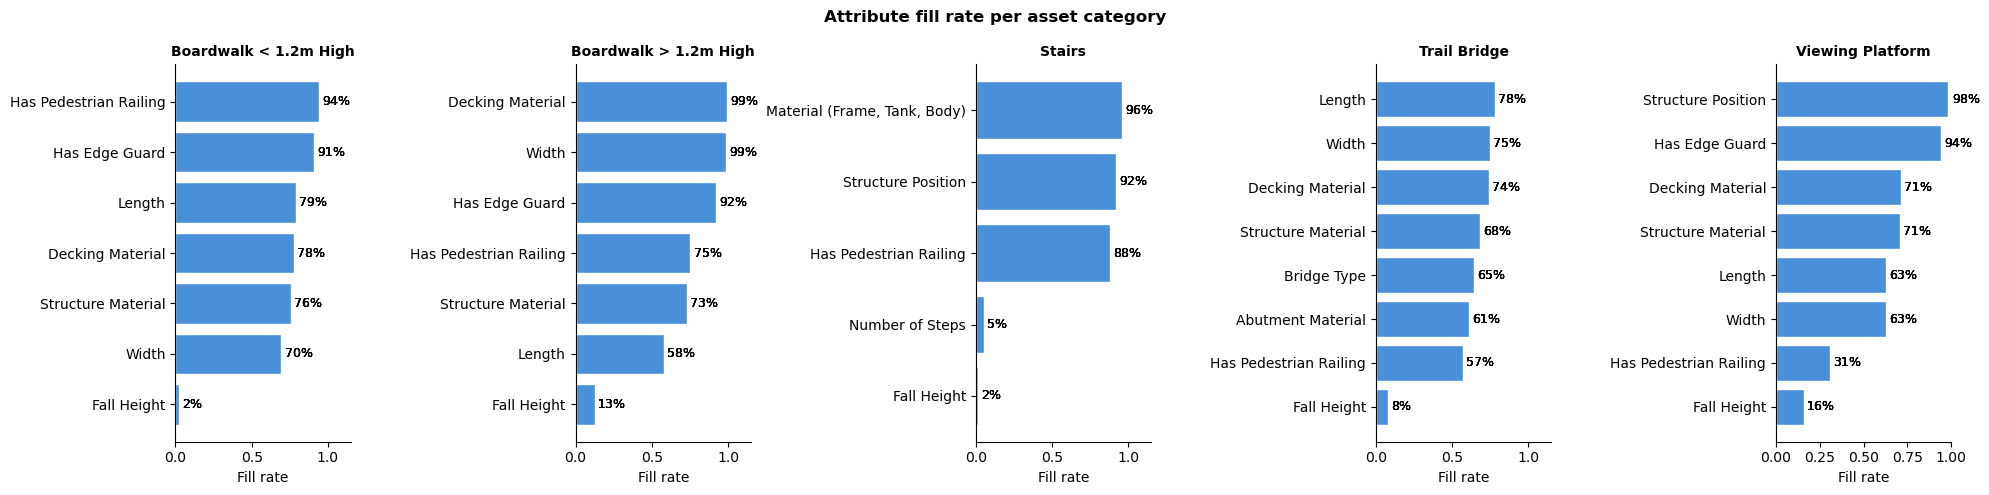

In [117]:
records = []

for category, info in PROFILE_ATTRS.items():
    subset = attributes_df[attributes_df["profile_name"] == category]
    for col in info["attrs"]:
        records.append({
            "category": category,
            "attr": col.replace("attr_", ""),
            "fill_rate": subset[col].apply(is_valid).mean(),
        })

fill_df = pd.DataFrame(records)

categories = list(PROFILE_ATTRS.keys())
fig, axes = plt.subplots(1, len(categories), figsize=(4 * len(categories), 5))

for ax, category in zip(axes, categories):
    data = fill_df[fill_df["category"] == category].sort_values("fill_rate")
    colors = "#4a90d9"
    ax.barh(data["attr"], data["fill_rate"], color=colors, edgecolor="white")
    for ax, category in zip(axes, categories):
        data = fill_df[fill_df["category"] == category].sort_values("fill_rate")
        ax.barh(data["attr"], data["fill_rate"], color="#4a90d9", edgecolor="white")
        
        # Add percentage labels
        for val, patch in zip(data["fill_rate"], ax.patches):
            ax.text(patch.get_width() + 0.02, patch.get_y() + patch.get_height() / 2,
                    f"{val:.0%}", va="center", fontsize=9)

        ax.set_xlim(0, 1.15)  # extend xlim slightly to make room for labels
        ax.set_title(category, fontsize=10, fontweight="bold")
        ax.set_xlabel("Fill rate")
        ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_title(category, fontsize=10, fontweight="bold")
    ax.set_xlabel("Fill rate")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Attribute fill rate per asset category", fontweight="bold")
plt.tight_layout()
plt.show()

### Class distributions per attribute

In [118]:
attributes_df["attr_Length"] = attributes_df["attr_Length"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")
attributes_df["attr_Width"] = attributes_df["attr_Width"].str.replace("m", "", regex=False).pipe(pd.to_numeric, errors="coerce")

In [124]:
num_attrs = ["attr_Fall Height", "attr_Number of Steps", "attr_Length", "attr_Width"]
cat_attrs = [col for col in attr_cols if col not in num_attrs]

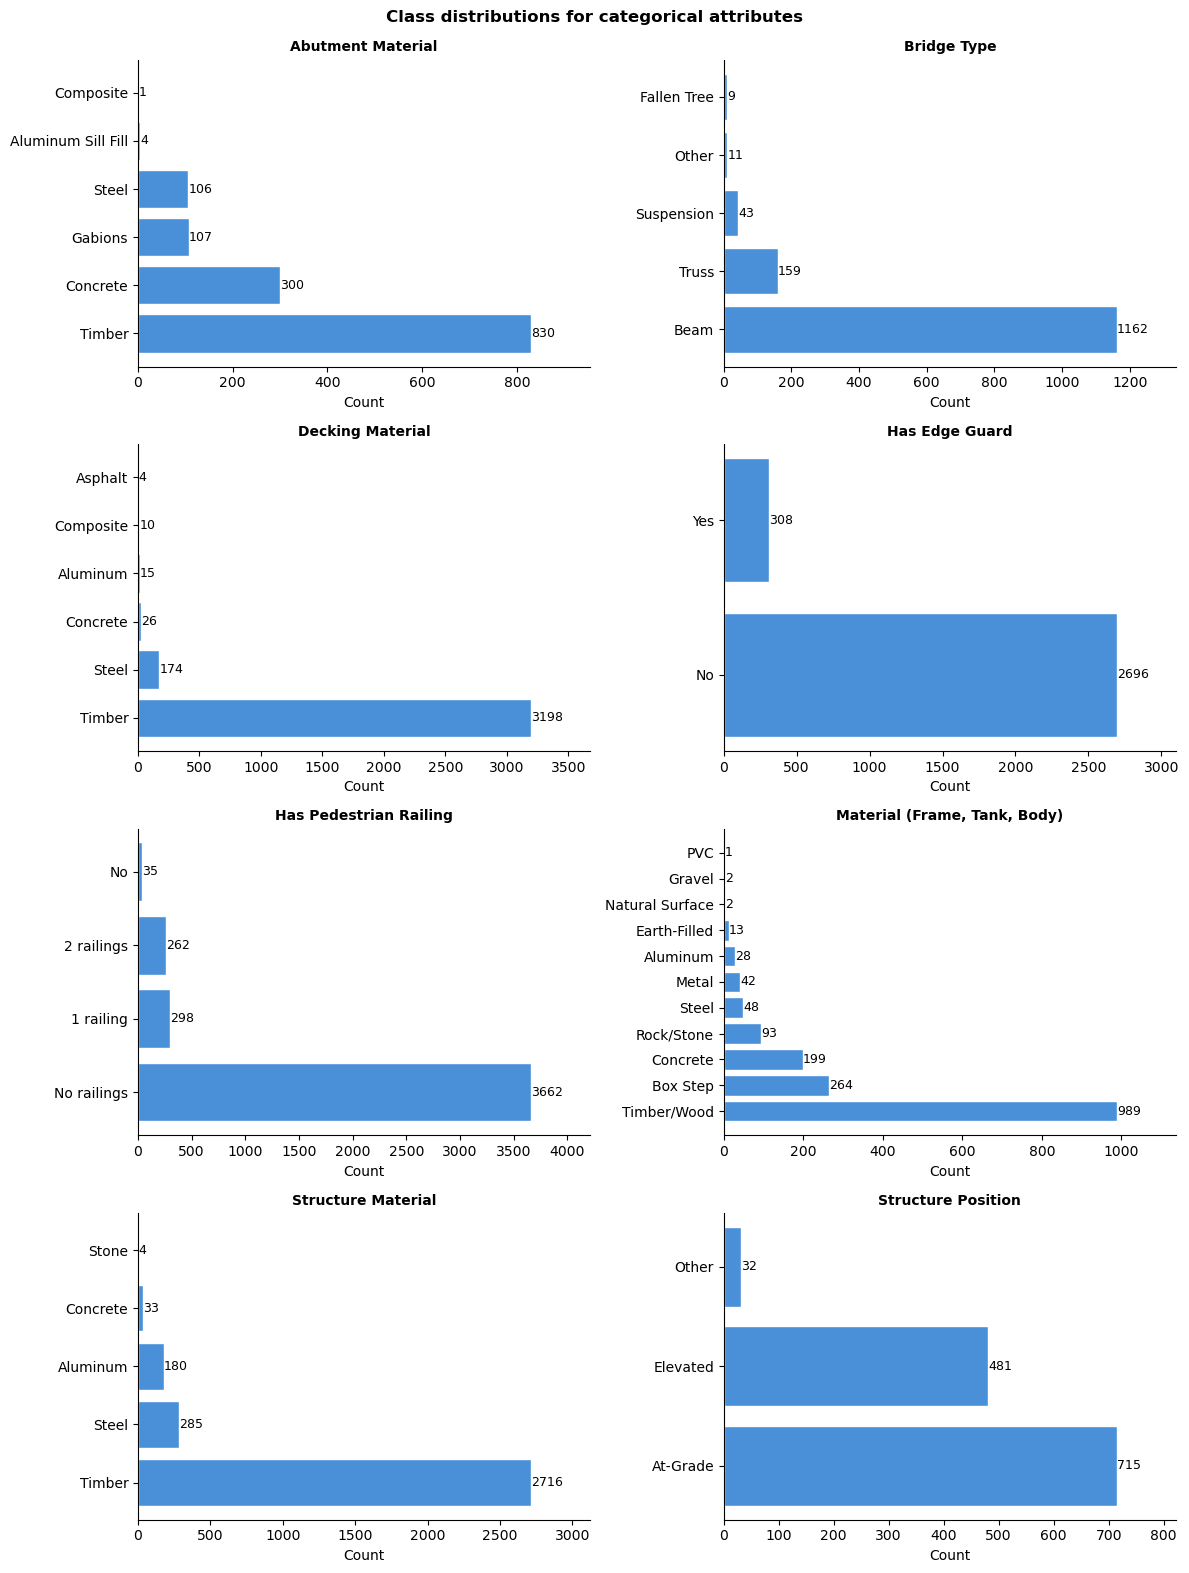

In [129]:
import math
import numpy as np

ncols = 2
nrows = math.ceil(len(cat_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

for ax, col in zip(axes, cat_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)]
    counts = valid_vals.value_counts()

    if counts.empty:
        ax.set_visible(False)
        continue

    bars = ax.barh(counts.index.astype(str), counts.values, color="#4a90d9", edgecolor="white")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)

    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_xlim(0, counts.values.max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(cat_attrs):]:
    ax.set_visible(False)

fig.suptitle("Class distributions for categorical attributes\n", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

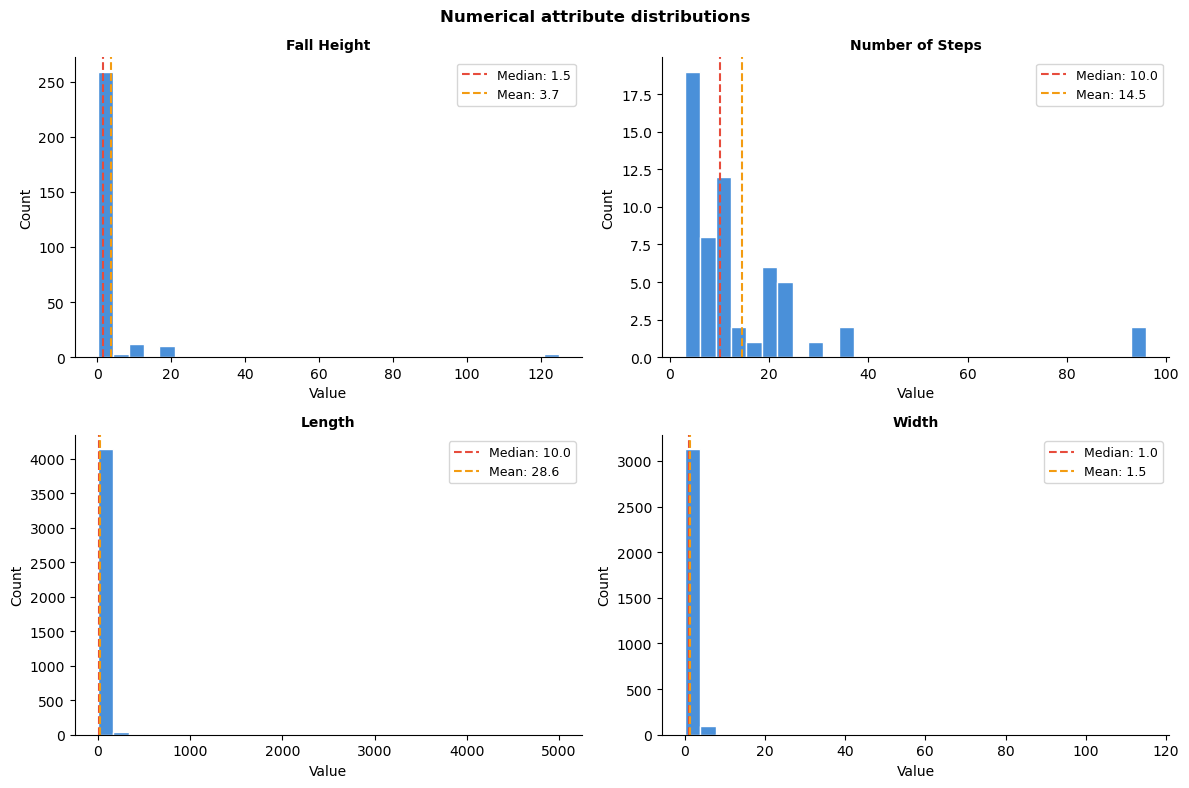

In [130]:
ncols = 2
nrows = math.ceil(len(num_attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 4))
axes = np.array(axes).flatten().tolist()

for ax, col in zip(axes, num_attrs):
    valid_vals = attributes_df[col][attributes_df[col].apply(is_valid)].dropna()

    ax.hist(valid_vals, bins=30, color="#4a90d9", edgecolor="white")
    ax.axvline(valid_vals.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Median: {valid_vals.median():.1f}")
    ax.axvline(valid_vals.mean(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mean: {valid_vals.mean():.1f}")
    ax.set_title(col.replace("attr_", ""), fontsize=10, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(num_attrs):]:
    ax.set_visible(False)

fig.suptitle("Numerical attribute distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()